In [ ]:
import torch
import lightning as L

# Check MPS availability
mps_available = torch.backends.mps.is_available()

if mps_available:
	device = "mps"
else:
	device = "cpu"

print(f"Using {device} device")
torch.set_default_device(device)

Using mps device


In [3]:
# set random seed for reproducibility
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    L.seed_everything(seed)

set_seed(42)

Seed set to 42


# Scrap TS Data

utilizing yahoofinance to get bbca stocks

In [4]:
import yfinance as yf
import pandas as pd

# Define the stock ticker and the date range
ticker = "BBCA.JK"
start_date = "2022-01-01"
end_date = "2024-01-01"

# Fetch the stock data
stock_data = yf.download(ticker, start=start_date, end=end_date)
# Display the first few rows of the data
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open     Volume
Ticker          BBCA.JK      BBCA.JK      BBCA.JK      BBCA.JK    BBCA.JK
Date                                                                     
2022-01-03  6573.094238  6640.395544  6550.660470  6573.094238   54287400
2022-01-04  6640.395020  6685.262553  6573.093719  6573.093719   70624000
2022-01-05  6685.263184  6752.564491  6617.961876  6685.263184   76164900
2022-01-06  6707.695801  6752.563331  6662.828270  6730.129566   63657100
2022-01-07  6864.732910  6909.600446  6730.130304  6774.997839  143433300


In [5]:
data = pd.DataFrame(
    {
        "Date": stock_data.index,
        "Close": stock_data[("Close", ticker)].values
    }
)

data

,Date,Close
0,2022-01-03,6573.094238
1,2022-01-04,6640.395020
2,2022-01-05,6685.263184
3,2022-01-06,6707.695801
4,2022-01-07,6864.732910
...,...,...
480,2023-12-21,8741.198242
481,2023-12-22,8741.198242
482,2023-12-27,8788.067383
483,2023-12-28,8811.502930


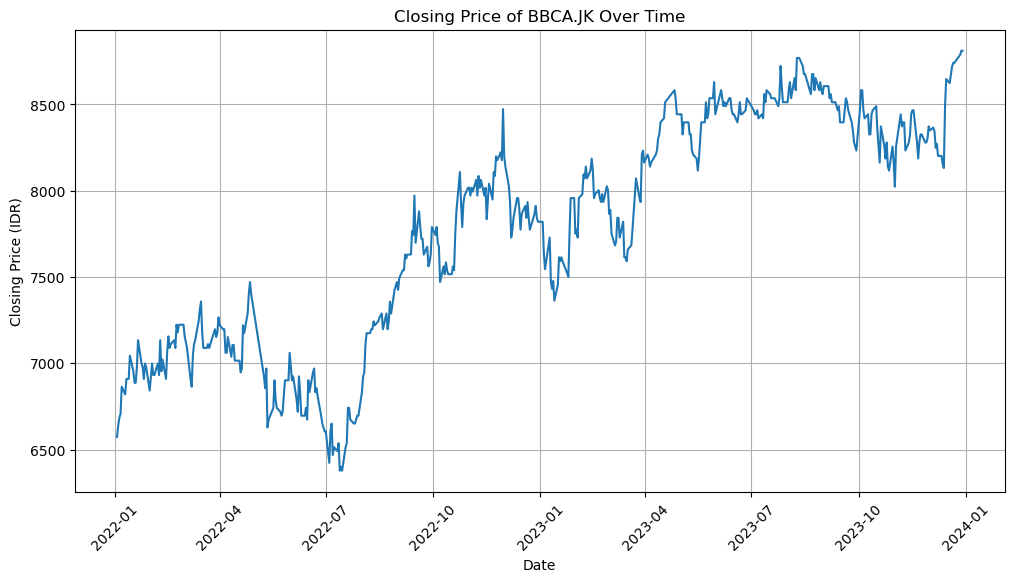

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the index to datetime
stock_data.index = pd.to_datetime(stock_data.index)
# Plot the closing price over time
plt.figure(figsize=(12, 6))
sns.lineplot(x=stock_data.index, y=stock_data[('Close', ticker)])
plt.title('Closing Price of BBCA.JK Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (IDR)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [7]:
stock_data.isna().sum()

Price   Ticker 
Close   BBCA.JK    0
High    BBCA.JK    0
Low     BBCA.JK    0
Open    BBCA.JK    0
Volume  BBCA.JK    0
dtype: int64

In [8]:
stock_data.shape

(485, 5)

# Split

In [9]:
# data.to_csv('bbca_closing_price_22_to_23.csv', index=True)

In [10]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [11]:
# Train and Test Interval
train_start = '2022-01-01'
train_end = '2023-06-30'
test_start = '2023-07-01'
test_end = '2024-01-01'
train_data = data[train_start:train_end]
test_data = data[test_start:test_end]

In [12]:
# train_data.to_csv('bbca_closing_price_22_to_23_train.csv', index=True)
# test_data.to_csv('bbca_closing_price_22_to_23_test.csv', index=True)

In [13]:
# Use device-agnostic code to automatically use MPS if available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


# Preprocesssing

In [14]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs, dtype=torch.float32).to(device), torch.tensor(ys, dtype=torch.float32).to(device)

from sklearn.preprocessing import MinMaxScaler

def scale_data(train, test):
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)
    return train_scaled, test_scaled, scaler

def make_dataloader(X, y, batch_size):
    dataset = torch.utils.data.TensorDataset(X, y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0)
    return dataloader

In [15]:
X_train, X_test, scaler = scale_data(train_data.values, test_data.values)

In [16]:
X_train, y_train = create_sequences(X_train, seq_length=30)
X_test, y_test = create_sequences(X_test, seq_length=30)

/opt/homebrew/Caskroom/miniconda/base/envs/ml_env/lib/python3.11/site-packages/torch/utils/_device.py:79: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1724788636145/work/torch/csrc/utils/tensor_new.cpp:281.)
  return func(*args, **kwargs)


# Model

In [17]:
# Get scaled dot-product attention from torch.nn.functional and MultiheadAttention from torch.nn
from torch.nn.functional import scaled_dot_product_attention
from torch.nn import MultiheadAttention
from torch import nn

# Get self attention single head from torch.nn
class SelfAttentionSingleHead(nn.Module):
    def __init__(self, embed_dim):
        super(SelfAttentionSingleHead, self).__init__()
        self.embed_dim = embed_dim
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        attn_output = scaled_dot_product_attention(Q, K, V)
        return attn_output

class SelfAttentionMultiHead(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(SelfAttentionMultiHead, self).__init__()
        self.multihead_attn = MultiheadAttention(embed_dim, num_heads)

    def forward(self, x):
        attn_output, _ = self.multihead_attn(x, x, x)
        return attn_output

In [ ]:
class BiLSTMWithMultiHeadAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_heads, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = SelfAttentionMultiHead(hidden_dim * 2, num_heads)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                 # (B, T, 2H)
        attn_out = self.attention(lstm_out)        # (B, T, 2H)
        attn_out = self.dropout(attn_out)
        # Context vector formed by weighted sum of all time steps
        context_vector = torch.mean(attn_out, dim=1)

        out = self.fc(context_vector)              # (B, output_dim)
        return out

class LSTMWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.attention = SelfAttentionSingleHead(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                 # (B, T, H)
        attn_out = self.attention(lstm_out)        # (B, T, H)
        attn_out = self.dropout(attn_out)
        # Context vector formed by weighted sum of all time steps
        context_vector = torch.mean(attn_out, dim=1)  # (B, H)
        out = self.fc(context_vector)              # (B, output_dim)
        return out

class BiLSTMWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = SelfAttentionSingleHead(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                 # (B, T, 2H)
        attn_out = self.attention(lstm_out)        # (B, T, 2H)
        attn_out = self.dropout(attn_out)
        # Context vector formed by weighted sum of all time steps
        context_vector = torch.mean(attn_out, dim=1)  # (B, 2H)
        out = self.fc(context_vector)              # (B, output_dim)
        return out

class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                 # (B, T, 2H)
        lstm_out = self.dropout(lstm_out)
        # Context vector formed by weighted sum of all time steps
        context_vector = torch.mean(lstm_out, dim=1)  # (B, 2H)
        out = self.fc(context_vector)              # (B, output_dim)
        return out


class CNN(nn.Module):
    def __init__(self, input_dim, num_filters, output_dim, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=num_filters, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=3)        # removes hard-coded sequence length dependency
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters, output_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1).contiguous()        # (B, input_dim, T)
        conv_out = torch.relu(self.conv1(x))       # (B, F, T')
        pooled = self.pool(conv_out)           # (B, F, T'')
        global_max, _ = torch.max(pooled, dim=2)  # (B, F)
        global_max = self.dropout(global_max)
        out = self.fc(global_max)                      # (B, output_dim)
        return out

class CNNWithAttention(nn.Module):
    def __init__(self, input_dim, num_filters, output_dim, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=num_filters, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.attention = SelfAttentionSingleHead(num_filters)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters, output_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1).contiguous()        # (B, input_dim, T)
        conv_out = torch.relu(self.conv1(x))       # (B, F, T')
        pooled_out = self.pool(conv_out)           # (B, F, T'')
        pooled_out = pooled_out.permute(0, 2, 1).contiguous()  # (B, T'', F)
        attn_out = self.attention(pooled_out)      # (B, T'', F)
        attn_out = self.dropout(attn_out)
        # Context vector formed by weighted sum of all time steps
        context_vector = torch.mean(attn_out, dim=1)  # (B, F)
        out = self.fc(context_vector)              # (B, output_dim)
        return out


class CNN_BiLSTM(nn.Module):
    def __init__(self, input_dim, num_filters, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=num_filters, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.lstm = nn.LSTM(num_filters, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1).contiguous()        # (B, input_dim, T)
        conv_out = torch.relu(self.conv1(x))       # (B, F, T')
        pooled_out = self.pool(conv_out)           # (B, F, T'')
        pooled_out = pooled_out.permute(0, 2, 1).contiguous()  # (B, T'', F)
        lstm_out, _ = self.lstm(pooled_out)        # (B, T'', 2H)
        lstm_out = self.dropout(lstm_out)
        # Context vector formed by weighted sum of all time steps
        context_vector = torch.mean(lstm_out, dim=1)  # (B, 2H)
        out = self.fc(context_vector)              # (B, output_dim)
        return out

class CNN_BiLSTMWithAttention(nn.Module):
    def __init__(self, input_dim, num_filters, hidden_dim, output_dim, num_heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=num_filters, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.lstm = nn.LSTM(num_filters, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = SelfAttentionSingleHead(hidden_dim * 2)  # Using single-head attention for simplicity
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1).contiguous()        # (B, input_dim, T)
        conv_out = torch.relu(self.conv1(x))       # (B, F, T')
        pooled_out = self.pool(conv_out)           # (B, F, T'')
        pooled_out = pooled_out.permute(0, 2, 1).contiguous()  # (B, T'', F)
        lstm_out, _ = self.lstm(pooled_out)        # (B, T'', 2H)
        attn_out = self.attention(lstm_out)        # (B, T'', 2H)
        attn_out = self.dropout(attn_out)
        # Context vector formed by weighted sum of all time steps
        context_vector = torch.mean(attn_out, dim=1)  # (B, 2H)
        out = self.fc(context_vector)              # (B, output_dim)
        return out

In [19]:
X_train

tensor([[[0.0868],
         [0.1166],
         [0.1366],
         ...,
         [0.2561],
         [0.2860],
         [0.2362]],

        [[0.1166],
         [0.1366],
         [0.1465],
         ...,
         [0.2860],
         [0.2362],
         [0.3059]],

        [[0.1366],
         [0.1465],
         [0.2163],
         ...,
         [0.2362],
         [0.3059],
         [0.3458]],

        ...,

        [[0.8654],
         [0.8654],
         [0.8239],
         ...,
         [0.9171],
         [0.9482],
         [0.9171]],

        [[0.8654],
         [0.8239],
         [0.8136],
         ...,
         [0.9482],
         [0.9171],
         [0.9171]],

        [[0.8239],
         [0.8136],
         [0.8032],
         ...,
         [0.9171],
         [0.9171],
         [0.9275]]], device='mps:0')

# Pipeline Experimental

In [ ]:
# Grid search setup
filters_grid = [32, 64, 128]
hidden_units_grid = [50, 100, 150]
dropout_grid = [0.1, 0.2, 0.3]
learning_rate_grid = [0.01, 0.001]
num_epochs_grid = [25, 50]
batch_size_grid = [15, 30]
val_days = 60

X_train_epoch = X_train[:-val_days]
y_train_epoch = y_train[:-val_days]
X_val_epoch = X_train[-val_days:]
y_val_epoch = y_train[-val_days:]

criterion = nn.MSELoss()
results = {}
model_build = {}
best_configs = {}

def build_model(name, hidden_dim=None, num_filters=None, dropout=0.2):
    if name == "BiLSTM":
        return BiLSTM(input_dim=1, hidden_dim=hidden_dim, output_dim=1, dropout=dropout).to(device)
    elif name == "BiLSTMWithAttention":
        return BiLSTMWithAttention(input_dim=1, hidden_dim=hidden_dim, output_dim=1, dropout=dropout).to(device)
    elif name == "BiLSTMWithMultiHeadAttention":
        return BiLSTMWithMultiHeadAttention(input_dim=1, hidden_dim=hidden_dim, output_dim=1, num_heads=4, dropout=dropout).to(device)
    elif name == "CNN":
        return CNN(input_dim=1, num_filters=num_filters, output_dim=1, dropout=dropout).to(device)
    elif name == "CNNwithAttention":
        return CNNWithAttention(input_dim=1, num_filters=num_filters, output_dim=1, dropout=dropout).to(device)
    elif name == "CNN_BiLSTM":
        return CNN_BiLSTM(input_dim=1, num_filters=num_filters, hidden_dim=hidden_dim, output_dim=1, dropout=dropout).to(device)
    elif name == "CNN_BiLSTMWithAttention":
        return CNN_BiLSTMWithAttention(input_dim=1, num_filters=num_filters, hidden_dim=hidden_dim, output_dim=1, num_heads=4, dropout=dropout).to(device)
    elif name == "LSTMWithAttention":
        return LSTMWithAttention(input_dim=1, hidden_dim=hidden_dim, output_dim=1, dropout=dropout).to(device)
    else:
        raise ValueError(f"Unknown model: {name}")

model_names = [
    "BiLSTM",
    "BiLSTMWithAttention",
    "BiLSTMWithMultiHeadAttention",
    "CNN",
    "CNNwithAttention",
    "CNN_BiLSTM",
    "CNN_BiLSTMWithAttention",
    "LSTMWithAttention"
]

for name in model_names:
    best_val_loss = float("inf")
    best_state = None
    best_params = None

    if name in ["BiLSTM", "BiLSTMWithAttention", "BiLSTMWithMultiHeadAttention", "LSTMWithAttention"]:
        arch_space = [(None, hd, dr) for hd in hidden_units_grid for dr in dropout_grid]
    elif name in ["CNN", "CNNwithAttention"]:
        arch_space = [(nf, None, dr) for nf in filters_grid for dr in dropout_grid]
    else:
        arch_space = [(nf, hd, dr) for nf in filters_grid for hd in hidden_units_grid for dr in dropout_grid]

    for nf, hd, dr in arch_space:
        for lr in learning_rate_grid:
            for epochs in num_epochs_grid:
                for bs in batch_size_grid:
                    train_loader = make_dataloader(X_train_epoch, y_train_epoch, batch_size=bs)
                    val_loader = make_dataloader(X_val_epoch, y_val_epoch, batch_size=bs)

                    model = build_model(name, hidden_dim=hd, num_filters=nf, dropout=dr)
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                    # Train
                    model.train()
                    for _ in range(epochs):
                        for xb, yb in train_loader:
                            optimizer.zero_grad()
                            out = model(xb)
                            loss = criterion(out, yb)
                            loss.backward()
                            optimizer.step()

                    # Validate
                    model.eval()
                    total_loss, total_count = 0.0, 0
                    with torch.no_grad():
                        for xb, yb in val_loader:
                            out = model(xb)
                            batch_loss = criterion(out, yb).item()
                            n_batch = xb.size(0)
                            total_loss += batch_loss * n_batch
                            total_count += n_batch

                    val_loss = total_loss / max(total_count, 1)

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        best_params = {
                            "num_filters": nf,
                            "hidden_dim": hd,
                            "dropout": dr,
                            "learning_rate": lr,
                            "epochs": epochs,
                            "batch_size": bs,
                        }
                        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_params is None or best_state is None:
        raise RuntimeError(f"No valid configuration found for model: {name}")

    best_model = build_model(
        name,
        hidden_dim=best_params["hidden_dim"],
        num_filters=best_params["num_filters"],
        dropout=best_params["dropout"],
    )
    best_model.load_state_dict(best_state)
    best_model.eval()

    with torch.no_grad():
        pred = best_model(X_val_epoch).detach().cpu().numpy()
        y_val_np = y_val_epoch.detach().cpu().numpy()

    pred_rescaled = scaler.inverse_transform(pred)
    y_val_rescaled = scaler.inverse_transform(y_val_np)

    mse_rescaled = float(((pred_rescaled - y_val_rescaled) ** 2).mean())
    rmse_rescaled = float(mse_rescaled ** 0.5)

    model_build[name] = best_model
    results[name] = (pred_rescaled, y_val_rescaled)
    best_configs[name] = {
        "best_params": best_params,
        "val_mse_scaled": best_val_loss,
        "val_mse_rescaled": mse_rescaled,
        "val_rmse_rescaled": rmse_rescaled,
    }

    print(f"{name} best params: {best_params}")
    print(f"{name} - Validation MSE (scaled): {best_val_loss:.6f}")
    print(f"{name} - Validation MSE (rescaled): {mse_rescaled:.4f}")
    print(f"{name} - Validation RMSE (rescaled): {rmse_rescaled:.4f}\n")

BiLSTM best params: {'num_filters': None, 'hidden_dim': 100, 'dropout': 0.3, 'learning_rate': 0.01, 'epochs': 25, 'batch_size': 15}
BiLSTM - Validation MSE (scaled): 0.007601
BiLSTM - Validation MSE (rescaled): 38548.6406
BiLSTM - Validation RMSE (rescaled): 196.3381

BiLSTMWithAttention best params: {'num_filters': None, 'hidden_dim': 50, 'dropout': 0.2, 'learning_rate': 0.01, 'epochs': 50, 'batch_size': 30}
BiLSTMWithAttention - Validation MSE (scaled): 0.001245
BiLSTMWithAttention - Validation MSE (rescaled): 6313.1377
BiLSTMWithAttention - Validation RMSE (rescaled): 79.4553

BiLSTMWithMultiHeadAttention best params: {'num_filters': None, 'hidden_dim': 150, 'dropout': 0.3, 'learning_rate': 0.001, 'epochs': 50, 'batch_size': 15}
BiLSTMWithMultiHeadAttention - Validation MSE (scaled): 0.004329
BiLSTMWithMultiHeadAttention - Validation MSE (rescaled): 60021.1641
BiLSTMWithMultiHeadAttention - Validation RMSE (rescaled): 244.9922

CNN best params: {'num_filters': 32, 'hidden_dim': None

## Try lightning

In [ ]:
import torch
import lightning as L

# BiLSTM best params: {'num_filters': None, 'hidden_dim': 100, 'dropout': 0.3, 'learning_rate': 0.01, 'epochs': 25, 'batch_size': 15}
# BiLSTM - Validation MSE (scaled): 0.007601
# BiLSTM - Validation MSE (rescaled): 38548.7734
# BiLSTM - Validation RMSE (rescaled): 196.3384

# BiLSTMWithAttention best params: {'num_filters': None, 'hidden_dim': 50, 'dropout': 0.2, 'learning_rate': 0.01, 'epochs': 50, 'batch_size': 30}
# BiLSTMWithAttention - Validation MSE (scaled): 0.001215
# BiLSTMWithAttention - Validation MSE (rescaled): 6163.3628
# BiLSTMWithAttention - Validation RMSE (rescaled): 78.5071

# BiLSTMWithMultiHeadAttention best params: {'num_filters': None, 'hidden_dim': 150, 'dropout': 0.3, 'learning_rate': 0.001, 'epochs': 50, 'batch_size': 15}
# BiLSTMWithMultiHeadAttention - Validation MSE (scaled): 0.004328
# BiLSTMWithMultiHeadAttention - Validation MSE (rescaled): 60012.4570
# BiLSTMWithMultiHeadAttention - Validation RMSE (rescaled): 244.9744

# CNN best params: {'num_filters': 32, 'hidden_dim': None, 'dropout': 0.3, 'learning_rate': 0.01, 'epochs': 25, 'batch_size': 15}
# CNN - Validation MSE (scaled): 0.001542
# CNN - Validation MSE (rescaled): 7820.2485
# CNN - Validation RMSE (rescaled): 88.4322

# CNNwithAttention best params: {'num_filters': 128, 'hidden_dim': None, 'dropout': 0.3, 'learning_rate': 0.001, 'epochs': 50, 'batch_size': 15}
# CNNwithAttention - Validation MSE (scaled): 0.001189
# CNNwithAttention - Validation MSE (rescaled): 6031.2246
# CNNwithAttention - Validation RMSE (rescaled): 77.6610

# CNN_BiLSTM best params: {'num_filters': 64, 'hidden_dim': 150, 'dropout': 0.3, 'learning_rate': 0.01, 'epochs': 50, 'batch_size': 15}
# CNN_BiLSTM - Validation MSE (scaled): 0.002366
# CNN_BiLSTM - Validation MSE (rescaled): 12001.5811
# CNN_BiLSTM - Validation RMSE (rescaled): 109.5517

# CNN_BiLSTMWithAttention best params: {'num_filters': 32, 'hidden_dim': 100, 'dropout': 0.3, 'learning_rate': 0.001, 'epochs': 50, 'batch_size': 15}
# CNN_BiLSTMWithAttention - Validation MSE (scaled): 0.001210
# CNN_BiLSTMWithAttention - Validation MSE (rescaled): 6138.1108
# CNN_BiLSTMWithAttention - Validation RMSE (rescaled): 78.3461

# LSTMWithAttention best params: {'num_filters': None, 'hidden_dim': 100, 'dropout': 0.3, 'learning_rate': 0.01, 'epochs': 50, 'batch_size': 30}
# LSTMWithAttention - Validation MSE (scaled): 0.004787
# LSTMWithAttention - Validation MSE (rescaled): 24279.6992
# LSTMWithAttention - Validation RMSE (rescaled): 155.8194

# Inisialisasi model sesuai best params dari grid search untuk masing-masing arsitektur
bilstm = BiLSTM(input_dim=1, hidden_dim=100, output_dim=1, dropout=0.3).to(device)
bilstm_attn = BiLSTMWithAttention(input_dim=1, hidden_dim=50, output_dim=1, dropout=0.2).to(device)
bilstm_multihead_attn = BiLSTMWithMultiHeadAttention(
    input_dim=1, hidden_dim=150, output_dim=1, num_heads=4, dropout=0.3
).to(device)

cnn = CNN(input_dim=1, num_filters=32, output_dim=1, dropout=0.3).to(device)
cnn_attn = CNNWithAttention(input_dim=1, num_filters=128, output_dim=1, dropout=0.3).to(device)

cnn_bilstm = CNN_BiLSTM(input_dim=1, num_filters=64, hidden_dim=150, output_dim=1, dropout=0.3).to(device)
cnn_bilstm_attn = CNN_BiLSTMWithAttention(
    input_dim=1, num_filters=32, hidden_dim=100, output_dim=1, num_heads=4, dropout=0.3
).to(device)

lstm_attn = LSTMWithAttention(input_dim=1, hidden_dim=100, output_dim=1, dropout=0.3).to(device)

# Define class untuk LightningModule
class TimeSeriesModel(L.LightningModule):
    def __init__(self, model, learning_rate):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.criterion = nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)
        loss = self.criterion(out, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)
        loss = self.criterion(out, y)
        self.log("val_loss", loss)

    def predict_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)
        return out

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)
    
val_days = 60
X_train_epoch = X_train[:-val_days]
y_train_epoch = y_train[:-val_days]
X_val_epoch = X_train[-val_days:]
y_val_epoch = y_train[-val_days:]

def build_train_validate(model, batch_size=None, learning_rate=None, epochs=None):
    train_loader = make_dataloader(X_train_epoch, y_train_epoch, batch_size=batch_size)
    val_loader = make_dataloader(X_val_epoch, y_val_epoch, batch_size=batch_size)
    test_loader = make_dataloader(X_test, y_test, batch_size=batch_size)

    lightning_model = TimeSeriesModel(model, learning_rate=learning_rate)
    trainer = L.Trainer(max_epochs=epochs, logger=False, enable_checkpointing=False)
    trainer.fit(lightning_model, train_loader, val_loader)

    return lightning_model, trainer, test_loader

In [ ]:
# Train and validate each model with best hyperparameters on comment and store the trained models in a dictionary
trained_models = {}
val_losses = {}
for name, model in model_build.items():
    params = best_configs[name]["best_params"]
    print(f"Training {name} with params: {params}")
    trained_model, trainer, test_loader = build_train_validate(
        model,
        batch_size=params["batch_size"],
        learning_rate=params["learning_rate"],
        epochs=params["epochs"],
    )
    trainer.validate(trained_model, test_loader)
    
    trained_models[name] = trained_model
    val_losses[name] = trainer.callback_metrics["val_loss"].item()
    # Save models weight in pth format
    torch.save(trained_model.state_dict(), f"{name}_best_model.pth")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training BiLSTM with params: {'num_filters': None, 'hidden_dim': 100, 'dropout': 0.3, 'learning_rate': 0.01, 'epochs': 25, 'batch_size': 15}


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BiLSTM  │ 82.6 K │ eval  │     0 │
│ 1 │ criterion │ MSELoss │      0 │ train │     0 │
└───┴───────────┴─────────┴────────┴───────┴───────┘

Trainable params: 82.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 82.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 4                                                                                            
Total FLOPs: 0

Output()

...

Trainable params: 71.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 71.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 8                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=50` reached.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │   0.011563398875296116    │
└───────────────────────────┴───────────────────────────┘

In [ ]:
# Sort models by validation loss and print the sorted results
sorted_models = sorted(val_losses.items(), key=lambda x: x[1])
print("Models sorted by validation loss:")
for name, val_loss in sorted_models:
    print(f"{name}: {val_loss:.6f}")

Models sorted by validation loss:
CNN_BiLSTMWithAttention: 0.001693
CNNwithAttention: 0.002305
BiLSTMWithAttention: 0.002515
CNN: 0.003075
BiLSTM: 0.006648
LSTMWithAttention: 0.011563
CNN_BiLSTM: 0.013044
BiLSTMWithMultiHeadAttention: 0.022599


In [ ]:
# # Save best configs in a JSON file
# import json

# with open("best_configs.json", "w") as f:
#     json.dump(best_configs, f, indent=4)

# # Save configs dalam format yaml
# import yaml

# with open("best_configs.yaml", "w") as f:
#     yaml.dump(best_configs, f)

## BiLSTM

In [ ]:
val_loss_list = []

## BiLSTM with Attention

In [ ]:
# Training BiLSTMWithAttention
bilstm_attn_module, bilstm_attn_trainer, bilstm_attn_test_loader = build_train_validate(
    bilstm_attn,
    batch_size=30,
    learning_rate=0.01,
    epochs=50
)

## BiLSTM with MultiheadAttention

In [ ]:
# Training BiLSTMWithMultiHeadAttention
bilstm_multihead_attn_module = TimeSeriesModel(bilstm_multihead_attn, learning_rate=0.001)
bilstm_multihead_attn_loader = make_dataloader(X_train_epoch, y_train_epoch, batch_size=15)
val_loader = make_dataloader(X_val_epoch, y_val_epoch, batch_size=15)
test_loader = make_dataloader(X_test, y_test, batch_size=15)
bilstm_multihead_attn_trainer = L.Trainer(max_epochs=50, accelerator="auto", log_every_n_steps=5)

bilstm_multihead_attn_trainer.fit(bilstm_multihead_attn_module, bilstm_multihead_attn_loader, val_loader)
bilstm_multihead_attn_trainer.validate(bilstm_multihead_attn_module, val_loader)
bilstm_multihead_attn_trainer.validate(bilstm_multihead_attn_module, test_loader)

val_loss_list.append(bilstm_multihead_attn_trainer.callback_metrics["val_loss"].item())

## CNN

In [ ]:
## Training CNN
cnn_module = TimeSeriesModel(cnn, learning_rate=0.01)
cnn_loader = make_dataloader(X_train_epoch, y_train_epoch, batch_size=15)
val_loader = make_dataloader(X_val_epoch, y_val_epoch, batch_size=15)
test_loader = make_dataloader(X_test, y_test, batch_size=15)
cnn_trainer = L.Trainer(max_epochs=25, accelerator="auto", log_every_n_steps=5)
cnn_trainer.fit(cnn_module, cnn_loader, val_loader)
cnn_trainer.validate(cnn_module, val_loader)
cnn_trainer.validate(cnn_module, test_loader)

val_loss_list.append(cnn_trainer.callback_metrics["val_loss"].item())

## CNN with Attention

In [ ]:
## Training CNN with Attention
cnn_attn_module = TimeSeriesModel(cnn_attn, learning_rate=0.01)
cnn_attn_loader = make_dataloader(X_train_epoch, y_train_epoch, batch_size=30)
val_loader = make_dataloader(X_val_epoch, y_val_epoch, batch_size=30)
test_loader = make_dataloader(X_test, y_test, batch_size=30)
cnn_attn_trainer = L.Trainer(max_epochs=25, accelerator="auto", log_every_n_steps=5)
cnn_attn_trainer.fit(cnn_attn_module, cnn_attn_loader, val_loader)
cnn_attn_trainer.validate(cnn_attn_module, val_loader)
cnn_attn_trainer.validate(cnn_attn_module, test_loader)

val_loss_list.append(cnn_attn_trainer.callback_metrics["val_loss"].item())

## CNN-BiLSTM

In [ ]:
## Training CNN-BiLSTM
cnn_bilstm_module = TimeSeriesModel(cnn_bilstm, learning_rate=0.001)
cnn_bilstm_loader = make_dataloader(X_train_epoch, y_train_epoch, batch_size=15)
val_loader = make_dataloader(X_val_epoch, y_val_epoch, batch_size=15)
test_loader = make_dataloader(X_test, y_test, batch_size=15)
cnn_bilstm_trainer = L.Trainer(max_epochs=25, accelerator="auto", log_every_n_steps=5)
cnn_bilstm_trainer.fit(cnn_bilstm_module, cnn_bilstm_loader, val_loader)
cnn_bilstm_trainer.validate(cnn_bilstm_module, val_loader)
cnn_bilstm_trainer.validate(cnn_bilstm_module, test_loader)

val_loss_list.append(cnn_bilstm_trainer.callback_metrics["val_loss"].item())

## CNN-BiLSTM with Attention

In [ ]:
# Training CNN-BiLSTM with Attention
cnn_bilstm_attn_module = TimeSeriesModel(cnn_bilstm_attn, learning_rate=0.001)
cnn_bilstm_attn_loader = make_dataloader(X_train_epoch, y_train_epoch, batch_size=15)
val_loader = make_dataloader(X_val_epoch, y_val_epoch, batch_size=15)
test_loader = make_dataloader(X_test, y_test, batch_size=15)
cnn_bilstm_attn_trainer = L.Trainer(max_epochs=50, accelerator="auto", log_every_n_steps=5)
cnn_bilstm_attn_trainer.fit(cnn_bilstm_attn_module, cnn_bilstm_attn_loader, val_loader)
cnn_bilstm_attn_trainer.validate(cnn_bilstm_attn_module, val_loader)
cnn_bilstm_attn_trainer.validate(cnn_bilstm_attn_module, test_loader)

val_loss_list.append(cnn_bilstm_attn_trainer.callback_metrics["val_loss"].item())

In [ ]:
val_loss_list = pd.DataFrame({
    "Model": ['BiLSTM', 'BiLSTMWithAttention', 'BiLSTMWithMultiHeadAttention', 'CNN', 'CNNwithAttention', 'CNN_BiLSTM', 'CNN_BiLSTMWithAttention'],
    "Validation Loss": val_loss_list
})

print(val_loss_list)

In [ ]:
val_loss_list = val_loss_list.sort_values("Validation Loss")
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Validation Loss", data=val_loss_list, palette="viridis")
plt.title("Validation Loss Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# Results

In [25]:
# Train and Test Interval
train_start = '2022-01-01'
train_end = '2023-06-30'
# Prediksi dari Juli 2023 sampai Januari 2024 (6 bulan ke depan)
test_start = '2023-06-01' # Ambil 1 bulan sebelumnya
test_end = '2024-01-01'
train_data = data[train_start:train_end]
test_data = data[test_start:test_end]

In [26]:
test_data

,Close
Date,
2023-06-05,8583.072266
2023-06-06,8536.424805
2023-06-07,8489.778320
2023-06-08,8513.101562
2023-06-09,8489.778320
...,...
2023-12-21,8741.198242
2023-12-22,8741.198242
2023-12-27,8788.067383


In [27]:
X_train, X_test, scaler = scale_data(train_data.values, test_data.values)

X_train, y_train = create_sequences(X_train, seq_length=30)
X_test, y_test = create_sequences(X_test, seq_length=30)

In [33]:
bilstm_test_loader = make_dataloader(X_test, y_test, batch_size=best_configs["BiLSTM"]["best_params"]["batch_size"])
bilstmwithattention_test_loader = make_dataloader(X_test, y_test, batch_size=best_configs["BiLSTMWithAttention"]["best_params"]["batch_size"])
bilstmwithmultiheadattention_test_loader = make_dataloader(X_test, y_test, batch_size=best_configs["BiLSTMWithMultiHeadAttention"]["best_params"]["batch_size"])
cnn_test_loader = make_dataloader(X_test, y_test, batch_size=best_configs["CNN"]["best_params"]["batch_size"])
cnnwithattention_test_loader = make_dataloader(X_test, y_test, batch_size=best_configs["CNNwithAttention"]["best_params"]["batch_size"])
cnn_bilstm_test_loader = make_dataloader(X_test, y_test, batch_size=best_configs["CNN_BiLSTM"]["best_params"]["batch_size"])
cnn_bilsstm_attn_test_loader = make_dataloader(X_test, y_test, batch_size=best_configs["CNN_BiLSTMWithAttention"]["best_params"]["batch_size"])
lstmwithattention_test_loader = make_dataloader(X_test, y_test, batch_size=best_configs["LSTMWithAttention"]["best_params"]["batch_size"])

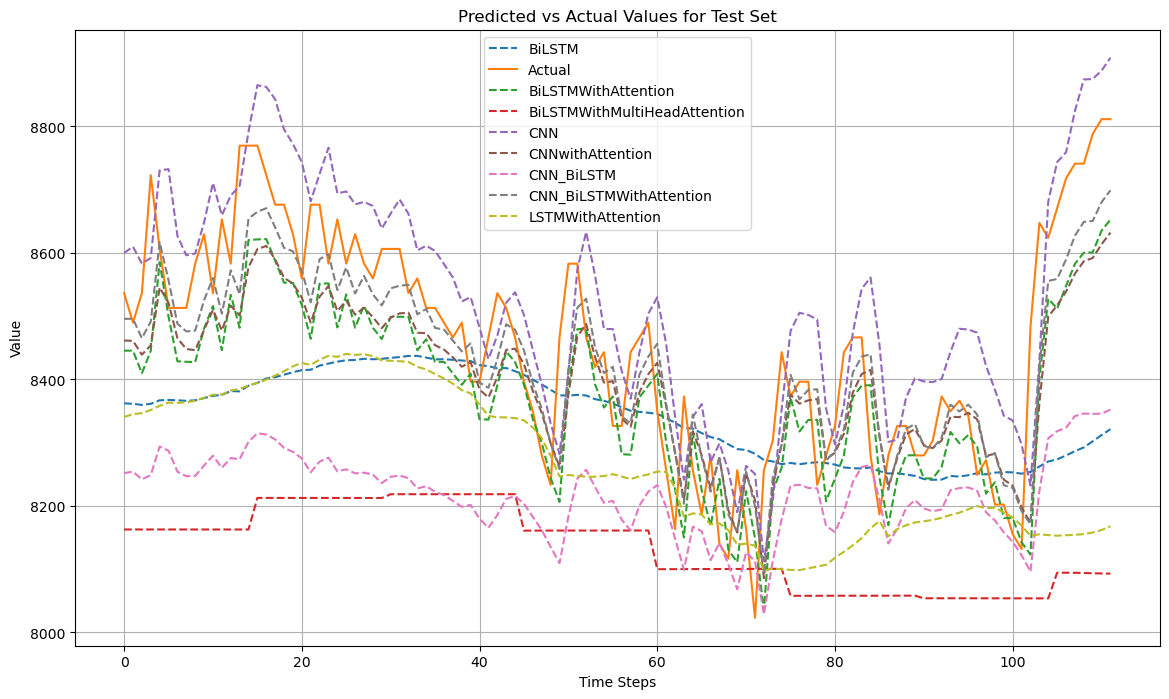

In [38]:
# Load best model .pth files
bilstm_checkpoint = "BiLSTM_best_model.pth"
bilstm_attn_checkpoint = "BiLSTMWithAttention_best_model.pth"
bilstm_multihead_attn_checkpoint = "BiLSTMWithMultiHeadAttention_best_model.pth"
cnn_checkpoint = "CNN_best_model.pth"
cnn_attn_checkpoint = "CNNwithAttention_best_model.pth"
cnn_bilstm_checkpoint = "CNN_BiLSTM_best_model.pth"
cnn_bilsstm_attn_checkpoint = "CNN_BiLSTMWithAttention_best_model.pth"
lstm_attn_checkpoint = "LSTMWithAttention_best_model.pth"

# Prediksi dengan model terbaik
def predict_and_evaluate(model, test_loader, scaler):
	device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
	model.to(device)
	model.eval()
	predictions, actuals = [], []
	with torch.no_grad():
		for xb, yb in test_loader:
			out = model(xb)
			predictions.append(out.cpu().numpy())
			actuals.append(yb.cpu().numpy())
	predictions = np.concatenate(predictions, axis=0)
	actuals = np.concatenate(actuals, axis=0)
	# Rescale kembali ke original scale
	predictions_rescaled = scaler.inverse_transform(predictions)
	actuals_rescaled = scaler.inverse_transform(actuals)
	mse_rescaled = float(((predictions_rescaled - actuals_rescaled) ** 2).mean())
	rmse_rescaled = float(mse_rescaled ** 0.5)
	return predictions_rescaled, actuals_rescaled, mse_rescaled, rmse_rescaled

# Visualisasi hasil prediksi vs actual untuk setiap model
bilsm_pred, bilstm_actual, bilstm_mse, bilstm_rmse = predict_and_evaluate(trained_models["BiLSTM"], bilstm_test_loader, scaler)
bilstm_attn_pred, bilstm_attn_actual, bilstm_attn_mse, bilstm_attn_rmse = predict_and_evaluate(trained_models["BiLSTMWithAttention"], bilstmwithattention_test_loader, scaler)
bilstm_multihead_attn_pred, bilstm_multihead_attn_actual, bilstm_multihead_attn_mse, bilstm_multihead_attn_rmse = predict_and_evaluate(trained_models["BiLSTMWithMultiHeadAttention"], bilstmwithmultiheadattention_test_loader, scaler)
cnn_pred, cnn_actual, cnn_mse, cnn_rmse = predict_and_evaluate(trained_models["CNN"], cnn_test_loader, scaler)
cnn_attn_pred, cnn_attn_actual, cnn_attn_mse, cnn_attn_rmse = predict_and_evaluate(trained_models["CNNwithAttention"], cnnwithattention_test_loader, scaler)
cnn_bilstm_pred, cnn_bilstm_actual, cnn_bilstm_mse, cnn_bilstm_rmse = predict_and_evaluate(trained_models["CNN_BiLSTM"], cnn_bilstm_test_loader, scaler)
cnn_bilstm_attn_pred, cnn_bilstm_attn_actual, cnn_bilstm_attn_mse, cnn_bilstm_attn_rmse = predict_and_evaluate(trained_models["CNN_BiLSTMWithAttention"], cnn_bilsstm_attn_test_loader, scaler)
lstm_attn_pred, lstm_attn_actual, lstm_attn_mse, lstm_attn_rmse = predict_and_evaluate(trained_models["LSTMWithAttention"], lstmwithattention_test_loader, scaler)

# Plot
plt.figure(figsize=(14, 8))
plt.plot(bilsm_pred, label="BiLSTM", linestyle="--")
plt.plot(bilstm_actual, label="Actual")
plt.plot(bilstm_attn_pred, label="BiLSTMWithAttention", linestyle="--")
plt.plot(bilstm_multihead_attn_pred, label="BiLSTMWithMultiHeadAttention", linestyle="--")
plt.plot(cnn_pred, label="CNN", linestyle="--")
plt.plot(cnn_attn_pred, label="CNNwithAttention", linestyle="--")
plt.plot(cnn_bilstm_pred, label="CNN_BiLSTM", linestyle="--")
plt.plot(cnn_bilstm_attn_pred, label="CNN_BiLSTMWithAttention", linestyle="--")
plt.plot(lstm_attn_pred, label="LSTMWithAttention", linestyle="--")
plt.title("Predicted vs Actual Values for Test Set")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()


some models work on very well, but there's also that mispredict too much i think it needs more analysis about the data and the model architecture itself